Seattle Airbnb — 30-Day Occupancy Efficiency Pipeline

Target: occupancy_rate_30 = estimated_occupancy_30 / 30 (0–1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
print("Libraries imported successfully — Ready to load and clean dataset.")

Libraries imported successfully — Ready to load and clean dataset.


DATA CLEANING + OUTLIERS + FEATURE ENGINEERING + EDA





In [2]:
#Load & Inspect
df = pd.read_excel("Seattle_new.xlsx")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (6862, 82)
Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'Unnamed: 40', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'avail

In [3]:
# Select Columns
final_features = [
    'property_type', 'room_type', 'neighbourhood_cleansed',
    'latitude', 'longitude',
    'accommodates', 'price',
    'estimated_occupancy_30', 'estimated_revenue_30',
    'availability_30', 'availability_365',
    'instant_bookable', 'host_since', 'host_is_superhost',
    'host_response_rate', 'host_total_listings_count',
    'number_of_reviews', 'review_scores_rating'
]

df = df[[c for c in final_features if c in df.columns]].copy()
df.columns = [c.strip().lower() for c in df.columns]
print("Columns kept:", df.columns.tolist())

Columns kept: ['property_type', 'room_type', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'price', 'estimated_occupancy_30', 'estimated_revenue_30', 'availability_30', 'availability_365', 'instant_bookable', 'host_since', 'host_is_superhost', 'host_response_rate', 'host_total_listings_count', 'number_of_reviews', 'review_scores_rating']


Numeric Cleaning

In [4]:
# price -> numeric
if 'price' in df.columns:
    df['price'] = (
        df['price'].astype(str)
        .str.replace(r'[^0-9.\-]', '', regex=True)
        .replace('', np.nan).astype(float)
    )
print("Price column cleaned and converted to numeric.")
print("Price column type →", df['price'].dtype)
print(df['price'].head())


Price column cleaned and converted to numeric.
Price column type → float64
0    123.0
1     88.0
2      NaN
3    310.0
4     96.0
Name: price, dtype: float64


In [5]:
# host_response_rate: "98%" -> 0.98
if 'host_response_rate' in df.columns:
    s = (df['host_response_rate'].astype(str)
         .str.replace('%', '', regex=False)
         .replace('', np.nan))
    s = pd.to_numeric(s, errors='coerce')
    df['host_response_rate'] = np.where(s > 1, s / 100, s)

for col in [
    'accommodates', 'estimated_occupancy_30', 'estimated_revenue_30',
    'availability_30', 'availability_365',
    'host_total_listings_count', 'number_of_reviews',
    'review_scores_rating', 'latitude', 'longitude'
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("host_response_rate cleaned → example values:")
print(df['host_response_rate'].head())

print("\nNumeric conversion complete. Sample preview:")
print(df[['accommodates','number_of_reviews','availability_30']].head())


host_response_rate cleaned → example values:
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: host_response_rate, dtype: float64

Numeric conversion complete. Sample preview:
   accommodates  number_of_reviews  availability_30
0             1                161                0
1             2                212               13
2             4                 96                0
3             8                 98               21
4             4               1119                4


In [6]:
# Impute 30-Day Occupancy & Revenue

if {'estimated_occupancy_30', 'availability_30'}.issubset(df.columns):
    mask_occ0 = (df['estimated_occupancy_30'] == 0) & (df['availability_30'] > 0)
    df.loc[mask_occ0, 'estimated_occupancy_30'] = 30 - df.loc[mask_occ0, 'availability_30']
    print("Imputed estimated_occupancy_30 for {mask_occ0.sum()} rows using availability_30")

if {'estimated_revenue_30', 'price', 'estimated_occupancy_30'}.issubset(df.columns):
    mask_rev0 = (
        (df['estimated_revenue_30'] == 0) &
        (df['estimated_occupancy_30'] > 0) &
        (df['price'] > 0)
    )
    df.loc[mask_rev0, 'estimated_revenue_30'] = (
        df.loc[mask_rev0, 'estimated_occupancy_30'] * df.loc[mask_rev0, 'price']
    )
    print(f"Imputed estimated_revenue_30 for {mask_rev0.sum()} rows using price × occupancy_30")

df['estimated_revenue_30'] = df['estimated_revenue_30'].clip(lower=0)


Imputed estimated_occupancy_30 for {mask_occ0.sum()} rows using availability_30
Imputed estimated_revenue_30 for 505 rows using price × occupancy_30


In [7]:
#  Boolean & Date
def to_binary(series):
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        't': 1, 'true': 1, 'yes': 1, 'y': 1, '1': 1,
        'f': 0, 'false': 0, 'no': 0, 'n': 0, '0': 0
    }
    return s.map(mapping).fillna(0).astype(int)

for col in ['instant_bookable', 'host_is_superhost']:
    if col in df.columns:
        df[col] = to_binary(df[col])

if 'host_since' in df.columns:
    hs = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years_active'] = ((pd.Timestamp('today') - hs).dt.days / 365)
    df.drop(columns=['host_since'], inplace=True)
else:
    df['host_years_active'] = np.nan
print(df[['instant_bookable','host_is_superhost','host_years_active']].head())

   instant_bookable  host_is_superhost  host_years_active
0                 0                  1          16.627397
1                 0                  1          16.339726
2                 0                  1          16.627397
3                 0                  1          16.627397
4                 1                  1          15.693151


In [8]:
#  Missing Value Imputation
num_cols_all = df.select_dtypes(include='number').columns
df[num_cols_all] = df[num_cols_all].apply(lambda x: x.fillna(x.median()))

cat_cols_all = df.select_dtypes(exclude='number').columns
for c in cat_cols_all:
    mode_val = df[c].mode().iloc[0] if not df[c].mode().empty else "Unknown"
    df[c] = df[c].fillna(mode_val)

print("Missing values handled.\n \n", df.isna().sum())

Missing values handled.
 
 property_type                0
room_type                    0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
accommodates                 0
price                        0
estimated_occupancy_30       0
estimated_revenue_30         0
availability_30              0
availability_365             0
instant_bookable             0
host_is_superhost            0
host_response_rate           0
host_total_listings_count    0
number_of_reviews            0
review_scores_rating         0
host_years_active            0
dtype: int64


In [9]:
# Outlier Handling (1–99 pct)
outlier_cols = [
    c for c in [
        'price', 'accommodates', 'number_of_reviews',
        'host_total_listings_count', 'review_scores_rating',
        'estimated_occupancy_30', 'estimated_revenue_30',
        'availability_30', 'availability_365',
        'host_years_active'
    ] if c in df.columns
]
for col in outlier_cols:
    q1, q99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=q1, upper=q99)
print(" Outliers clipped (1–99 pct).")

 Outliers clipped (1–99 pct).


In [10]:
#   Create Target: occupancy_rate_30
if 'estimated_occupancy_30' in df.columns:
    df['occupancy_rate_30'] = (df['estimated_occupancy_30'] / 30).astype(float)
    df['occupancy_rate_30'] = df['occupancy_rate_30'].clip(0, 1)
else:
    raise ValueError("estimated_occupancy_30 not found; cannot build occupancy_rate_30.")
print("occupancy_rate_30 created (0–1).")

occupancy_rate_30 created (0–1).


In [11]:
# Logical Consistency
if 'price' in df.columns:
    df = df[df['price'] > 0]
if 'accommodates' in df.columns:
    df = df[df['accommodates'] >= 1]

print("Logical consistency enforced.")
print("Current shape:", df.shape)

Logical consistency enforced.
Current shape: (6862, 19)


In [12]:
#  Handle Skewed Predictors
if 'price' in df.columns:
    df['log_price'] = np.log1p(df['price'])
if 'number_of_reviews' in df.columns:
    df['log_reviews'] = np.log1p(df['number_of_reviews'])
if 'estimated_revenue_30' in df.columns:
    df['log_estimated_revenue_30'] = np.log1p(df['estimated_revenue_30'])
    print(df[['price','log_price','number_of_reviews','log_reviews','estimated_revenue_30','log_estimated_revenue_30']].head())


   price  log_price  number_of_reviews  log_reviews  estimated_revenue_30  \
0  123.0   4.820282             161.00     5.087596            606.575342   
1   88.0   4.488636             212.00     5.361292            650.958904   
2  177.0   5.181784              96.00     4.574711              0.000000   
3  310.0   5.739793              98.00     4.595120           2790.000000   
4   96.0   4.574711             595.17     6.390526           2012.054795   

   log_estimated_revenue_30  
0                  6.409476  
1                  6.479982  
2                  0.000000  
3                  7.934155  
4                  7.607409  


In [13]:
#   Location Feature: distance to Downtown
def haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

if {'latitude', 'longitude'}.issubset(df.columns):
    df['dist_km_downtown'] = haversine(
        df['latitude'], df['longitude'], 47.6062, -122.3321
    )
    print(" Engineered feature: dist_km_downtown")

 Engineered feature: dist_km_downtown


In [14]:
# keep top-10 neighbourhoods; others -> "Other"
if 'neighbourhood_cleansed' in df.columns:
    top_neigh = df['neighbourhood_cleansed'].value_counts().nlargest(10).index
    df['neighbourhood_cleansed'] = np.where(
        df['neighbourhood_cleansed'].isin(top_neigh),
        df['neighbourhood_cleansed'],
        'Other'
    )
print("Neighbourhood categories consolidated — top 10 retained, others grouped as 'Other'.")
print(df['neighbourhood_cleansed'].value_counts().head(11))

Neighbourhood categories consolidated — top 10 retained, others grouped as 'Other'.
neighbourhood_cleansed
Other                        4457
Belltown                      383
Broadway                      376
University District           277
Wallingford                   264
Fremont                       249
Minor                         246
North Beacon Hill             162
West Queen Anne               155
Atlantic                      147
Central Business District     146
Name: count, dtype: int64


In [15]:
# Encode Categoricals
for col in ['property_type', 'room_type', 'neighbourhood_cleansed']:
    if col in df.columns:
        if col == 'property_type':
            freq = df[col].value_counts(normalize=True)
            rare = freq[freq < 0.01].index
            df[col] = df[col].replace(rare, 'Other')
        df = pd.get_dummies(df, columns=[col], drop_first=True)
print("Categorical encoding complete. New shape:", df.shape)

Categorical encoding complete. New shape: (6862, 44)


VIF

In [16]:
#  VIF (Multicollinearity)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    def compute_vif(X):
        X_ = X.select_dtypes(include='number').copy()
        X_ = X_.replace([np.inf, -np.inf], np.nan).fillna(0)
        vifs = []
        cols = X_.columns.tolist()
        for i in range(len(cols)):
            vifs.append(variance_inflation_factor(X_.values, i))
        return pd.DataFrame({'feature': cols, 'vif': vifs})

    target_col = 'occupancy_rate_30'
    drop_leak = ['estimated_occupancy_30']
    X_vif = df.drop(columns=[c for c in drop_leak if c in df.columns] + [target_col])

    max_iter = 5
    for _ in range(max_iter):
        vif_df = compute_vif(X_vif)
        worst = vif_df.sort_values('vif', ascending=False).iloc[0]
        if worst['vif'] <= 10:
            break
        to_drop = worst['feature']
        if to_drop == 'price' and 'log_price' in X_vif.columns:
            to_drop = 'price'
        X_vif = X_vif.drop(columns=[to_drop])
        print(f" Dropped high-VIF feature: {to_drop} (VIF={worst['vif']:.2f})")

    keep_cols = X_vif.columns.tolist() + [target_col]
    df = df[keep_cols]
    print(" VIF reduction complete. Final cols:", len(keep_cols))
except Exception as e:
    print(f"ℹ Skipping VIF step ({e}). Proceeding with current features.")

print(df.describe().T.head(12))

 Dropped high-VIF feature: longitude (VIF=1040948.08)
 Dropped high-VIF feature: latitude (VIF=777.34)
 Dropped high-VIF feature: log_price (VIF=328.69)
 Dropped high-VIF feature: review_scores_rating (VIF=78.27)
 Dropped high-VIF feature: host_response_rate (VIF=20.53)
 VIF reduction complete. Final cols: 38
                            count         mean          std        min  \
accommodates               6862.0     4.059749     2.588121   1.000000   
price                      6862.0   219.873110   168.111992  45.000000   
estimated_revenue_30       6862.0  2014.916289  2452.193888   0.000000   
availability_30            6862.0     7.644419     8.415119   0.000000   
availability_365           6862.0   198.725299   116.359263   0.000000   
instant_bookable           6862.0     0.325707     0.468672   0.000000   
host_is_superhost          6862.0     0.522734     0.499519   0.000000   
host_total_listings_count  6862.0   359.051880  1285.065383   1.000000   
number_of_reviews      

Exploratory Data Analysis

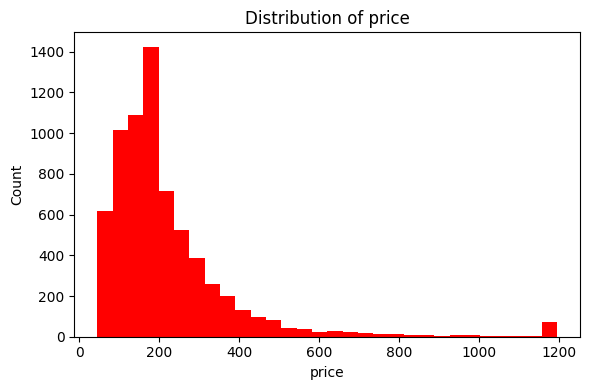

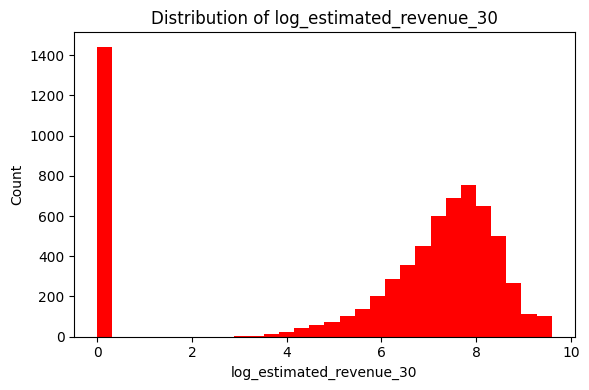

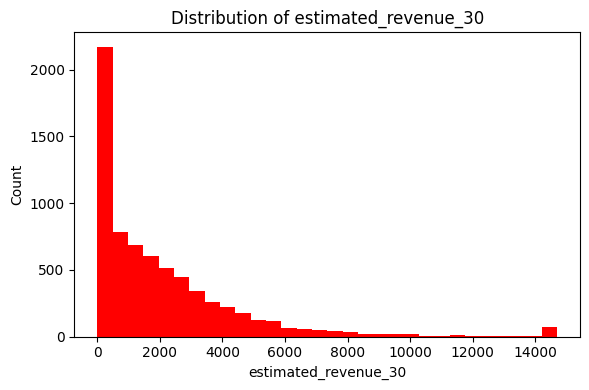

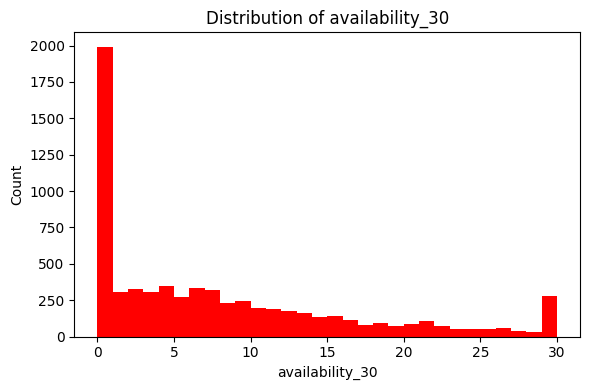

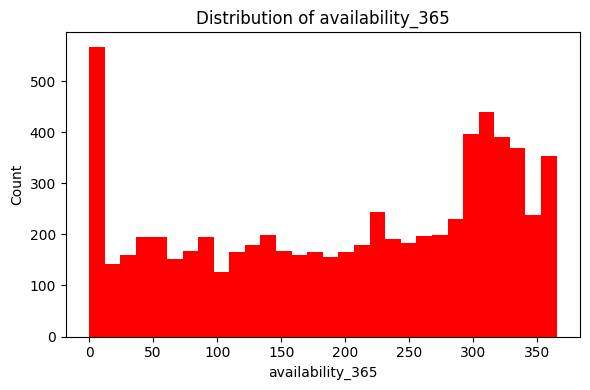

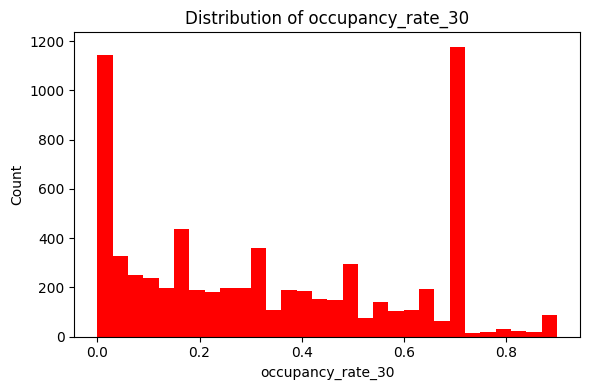

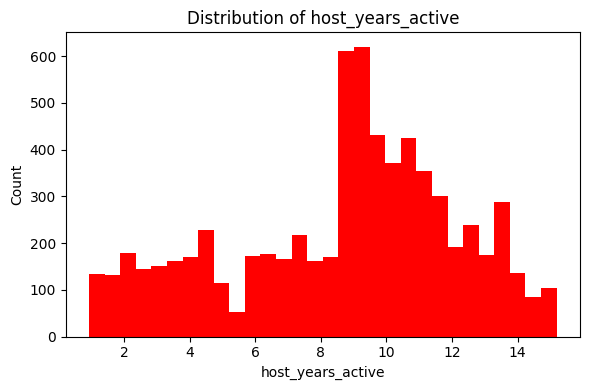

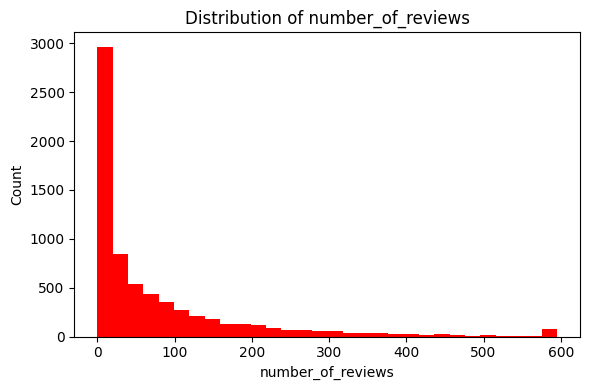

In [17]:
#  EDA GRAPHS (ALL RED)
# Histograms
eda_num_cols = [
    'price',
    'log_estimated_revenue_30',
    'estimated_revenue_30',
    'availability_30',
    'availability_365',
    'occupancy_rate_30',
    'host_years_active',
    'number_of_reviews'
]
for col in eda_num_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        plt.hist(df[col], bins=30, color='red')
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()


In [18]:
# Categorical bar plots
cat_cols_eda = ['room_type', 'property_type', 'neighbourhood_cleansed']
for col in cat_cols_eda:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        df[col].value_counts().head(15).plot(kind='bar', color='red')
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"{col} frequency (top categories)")
        plt.tight_layout()
        plt.show()
print(df.columns.tolist())
for col in cat_cols_eda:
    print(col, "→", col in df.columns)

    generated = []

for col in cat_cols_eda:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        df[col].value_counts().head(15).plot(kind='bar', color='red')
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"{col} frequency (top categories)")
        plt.tight_layout()
        plt.show()
        generated.append(col)

if generated:
    print("Plots generated for:", generated)
else:
    print("No categorical plots created — specified columns not found in dataset.")


['accommodates', 'price', 'estimated_revenue_30', 'availability_30', 'availability_365', 'instant_bookable', 'host_is_superhost', 'host_total_listings_count', 'number_of_reviews', 'host_years_active', 'log_reviews', 'log_estimated_revenue_30', 'dist_km_downtown', 'property_type_Entire guest suite', 'property_type_Entire guesthouse', 'property_type_Entire home', 'property_type_Entire rental unit', 'property_type_Entire townhouse', 'property_type_Other', 'property_type_Private room in home', 'property_type_Private room in rental unit', 'property_type_Private room in townhouse', 'property_type_Room in boutique hotel', 'property_type_Room in hotel', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_cleansed_Belltown', 'neighbourhood_cleansed_Broadway', 'neighbourhood_cleansed_Central Business District', 'neighbourhood_cleansed_Fremont', 'neighbourhood_cleansed_Minor', 'neighbourhood_cleansed_North Beacon Hill', 'neighbourhood_cleansed_Other', 'neighb

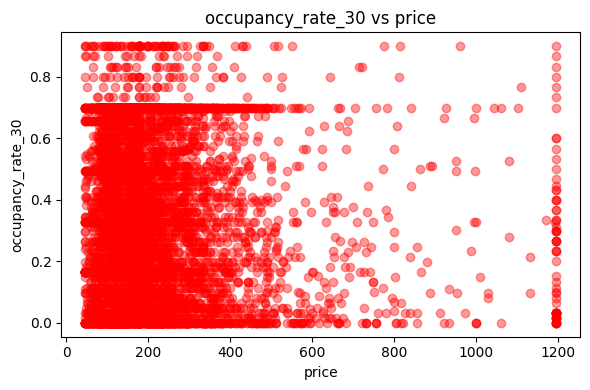

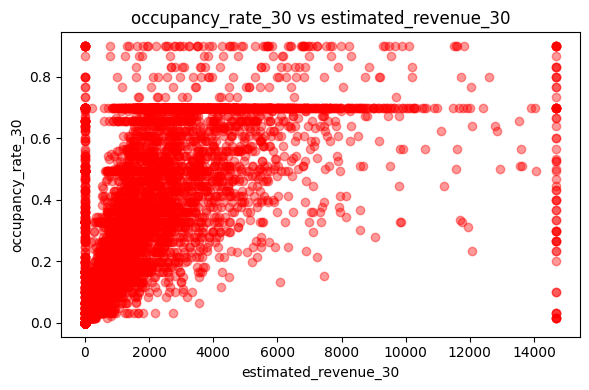

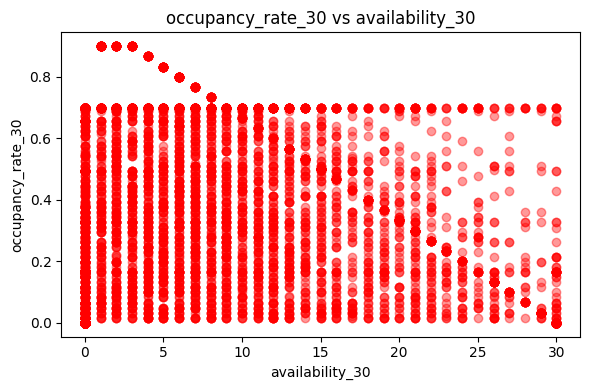

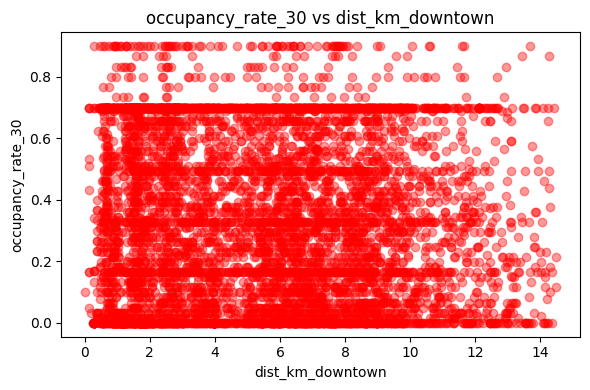

In [19]:
# Scatter vs occupancy_rate_30
scatter_pairs = [
    ('price', 'occupancy_rate_30'),
    ('estimated_revenue_30', 'occupancy_rate_30'),
    ('availability_30', 'occupancy_rate_30'),
    ('dist_km_downtown', 'occupancy_rate_30')
]
for x_col, y_col in scatter_pairs:
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[x_col], df[y_col], alpha=0.4, color='red')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} vs {x_col}")
        plt.tight_layout()
        plt.show()


Correlation Heatmap


 Correlation Matrix (numeric) 
 
                      price  estimated_revenue_30  availability_30  \
price                 1.000                 0.562            0.214   
estimated_revenue_30  0.562                 1.000            0.081   
availability_30       0.214                 0.081            1.000   
availability_365      0.145                 0.110            0.296   
occupancy_rate_30    -0.071                 0.599           -0.059   
number_of_reviews    -0.127                 0.204           -0.062   
host_years_active    -0.106                -0.023           -0.164   

                      availability_365  occupancy_rate_30  number_of_reviews  \
price                            0.145             -0.071             -0.127   
estimated_revenue_30             0.110              0.599              0.204   
availability_30                  0.296             -0.059             -0.062   
availability_365                 1.000             -0.044             -0.060   
occup

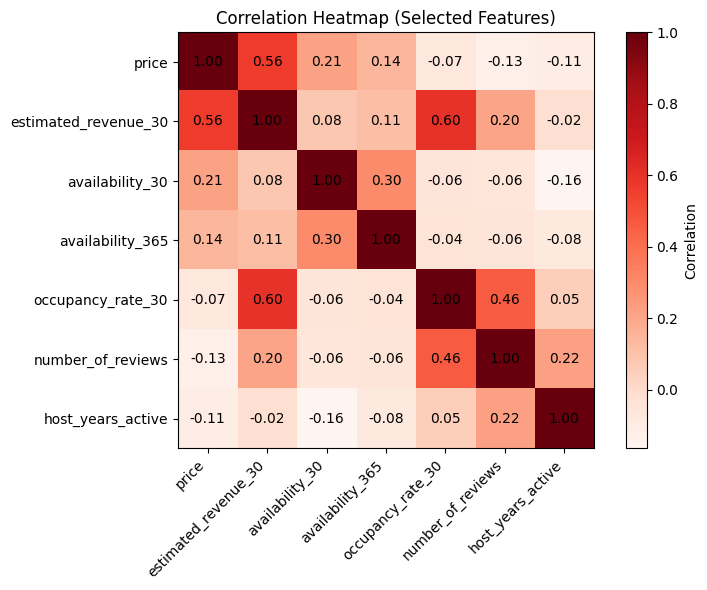

In [20]:
# Correlation heatmap with values
corr_cols = [
    'price', 'estimated_occupancy_30', 'estimated_revenue_30',
    'availability_30', 'availability_365', 'occupancy_rate_30',
    'number_of_reviews', 'host_years_active'
]
corr_cols = [c for c in corr_cols if c in df.columns]
if len(corr_cols) >= 2:
    corr_mat = df[corr_cols].corr()
    print("\n Correlation Matrix (numeric) \n ")
    print(corr_mat.round(3))

    plt.figure(figsize=(8, 6))
    im = plt.imshow(corr_mat, interpolation='nearest', cmap='Reds')
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.colorbar(im, label='Correlation')

    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            val = corr_mat.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

    plt.title("Correlation Heatmap (Selected Features)")
    plt.tight_layout()
    plt.show()

In [21]:
# BINARY CLASSIFICATION PREP (Very High vs Rest)

target_col = 'occupancy_rate_30'
y_cont = df[target_col]
X_all = df.drop(columns=[target_col])

print("Shape of X_all:", X_all.shape)
print("Shape of y_cont:", y_cont.shape)
print("\nSample target values:")
print(y_cont.head())


Shape of X_all: (6862, 37)
Shape of y_cont: (6862,)

Sample target values:
0    0.164384
1    0.246575
2    0.000000
3    0.300000
4    0.698630
Name: occupancy_rate_30, dtype: float64


Target converted into quartile-based classes (0=low, 3=very high)

In [22]:
# Quartile-based 0–3
y_class = pd.qcut(y_cont, q=4, labels=False, duplicates='drop')
print("Target converted into quartile-based classes (0=low, 3=very high).")
print(y_class.value_counts())

Target converted into quartile-based classes (0=low, 3=very high).
occupancy_rate_30
1    1741
2    1727
0    1719
3    1675
Name: count, dtype: int64


In [23]:
# Binary: Very High (top quartile) = 1, others = 0
y_bin = (y_class == y_class.max()).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_all, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

num_cols_b = X_train_b.select_dtypes(include='number').columns.tolist()
preprocess_clf = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols_b)],
    remainder='passthrough'
)
print("Classification preprocessor ready.")


Classification preprocessor ready.


Linear Regression Model

In [24]:
# LINEAR REGRESSION MODEL (Continuous occupancy_rate_30)
try:
    y_bins_reg = pd.qcut(y_cont, q=5, labels=False, duplicates='drop')
except ValueError:
    y_bins_reg = pd.qcut(y_cont.rank(method='first'), q=5, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_cont, test_size=0.2, stratify=y_bins_reg, random_state=42
)

num_cols_reg = X_train.select_dtypes(include='number').columns.tolist()
preprocess_reg = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols_reg)],
    remainder='passthrough'
)

linreg_pipe = Pipeline([
    ('pp', preprocess_reg),
    ('lr', LinearRegression())
])

linreg_pipe.fit(X_train, y_train)
y_pred_train = linreg_pipe.predict(X_train)
y_pred_test = linreg_pipe.predict(X_test)

results_lr = {
    'Model': 'Linear Regression',
    'Train_R2': r2_score(y_train, y_pred_train),
    'Test_R2': r2_score(y_test, y_pred_test),
    'Test_MAE': mean_absolute_error(y_test, y_pred_test),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
}
print("\n Linear Regression Summary:")
print(pd.DataFrame([results_lr]).round(4))



 Linear Regression Summary:
               Model  Train_R2  Test_R2  Test_MAE  Test_RMSE
0  Linear Regression    0.6795   0.6927    0.1088     0.1475


To find best cutoff value.

Logistic Regression 0.1-0.9


In [25]:
#  LOGISTIC REGRESSION 0.1–0.9 THRESHOLDS (Binary)

logistic_bin_pipe = Pipeline([
    ('pp', preprocess_clf),
    ('logr', LogisticRegression(max_iter=500))
])

logistic_bin_pipe.fit(X_train_b, y_train_b)
y_proba = logistic_bin_pipe.predict_proba(X_test_b)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)

print(" Binary Logistic – Thresholds ")

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_b, y_pred_thr).ravel()
    acc = accuracy_score(y_test_b, y_pred_thr)

    print(f"\nThreshold = {thr:.1f}")
    print(f"TP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")
    print(f"Accuracy: {acc:.4f}")

 Binary Logistic – Thresholds 

Threshold = 0.1
TP: 303  FP: 198  TN: 840  FN: 32
Accuracy: 0.8325

Threshold = 0.2
TP: 301  FP: 132  TN: 906  FN: 34
Accuracy: 0.8791

Threshold = 0.3
TP: 293  FP: 85  TN: 953  FN: 42
Accuracy: 0.9075

Threshold = 0.4
TP: 287  FP: 60  TN: 978  FN: 48
Accuracy: 0.9213

Threshold = 0.5
TP: 269  FP: 46  TN: 992  FN: 66
Accuracy: 0.9184

Threshold = 0.6
TP: 252  FP: 25  TN: 1013  FN: 83
Accuracy: 0.9213

Threshold = 0.7
TP: 231  FP: 14  TN: 1024  FN: 104
Accuracy: 0.9141

Threshold = 0.8
TP: 189  FP: 3  TN: 1035  FN: 146
Accuracy: 0.8915

Threshold = 0.9
TP: 134  FP: 0  TN: 1038  FN: 201
Accuracy: 0.8536


Threshold Evaluation Table

In [26]:
# Detailed threshold metrics (Precision, Recall, F1)
results_thr = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_b, y_pred_thr).ravel()
    precision = precision_score(y_test_b, y_pred_thr, zero_division=0)
    recall_val = recall_score(y_test_b, y_pred_thr, zero_division=0)
    f1_val = f1_score(y_test_b, y_pred_thr, zero_division=0)

    results_thr.append({
        'Threshold': thr,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'Precision': precision,
        'Recall': recall_val,
        'F1_score': f1_val
    })

threshold_df = pd.DataFrame(results_thr)

print("  Threshold Evaluation Table  ")

print(threshold_df.round(4))

  Threshold Evaluation Table  
   Threshold   TP   FP    TN   FN  Precision  Recall  F1_score
0        0.1  303  198   840   32     0.6048  0.9045    0.7249
1        0.2  301  132   906   34     0.6952  0.8985    0.7839
2        0.3  293   85   953   42     0.7751  0.8746    0.8219
3        0.4  287   60   978   48     0.8271  0.8567    0.8416
4        0.5  269   46   992   66     0.8540  0.8030    0.8277
5        0.6  252   25  1013   83     0.9097  0.7522    0.8235
6        0.7  231   14  1024  104     0.9429  0.6896    0.7966
7        0.8  189    3  1035  146     0.9844  0.5642    0.7173
8        0.9  134    0  1038  201     1.0000  0.4000    0.5714


youden's j statistic

In [27]:
# J-STATS (Youden's J) FOR THRESHOLDS

j_stats = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_b, y_pred_thr).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    j_val = sensitivity + specificity - 1

    j_stats.append({
        'Threshold': thr,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'Sensitivity_Recall': sensitivity,
        'Specificity': specificity,
        'J_stat': j_val
    })

j_stats_df = pd.DataFrame(j_stats)

print("                        Youden's J Table        ")
print(f"____________________________________________________________________________")
print(j_stats_df.round(4))

                        Youden's J Table        
____________________________________________________________________________
   Threshold   TP   FP    TN   FN  Sensitivity_Recall  Specificity  J_stat
0        0.1  303  198   840   32              0.9045       0.8092  0.7137
1        0.2  301  132   906   34              0.8985       0.8728  0.7713
2        0.3  293   85   953   42              0.8746       0.9181  0.7927
3        0.4  287   60   978   48              0.8567       0.9422  0.7989
4        0.5  269   46   992   66              0.8030       0.9557  0.7587
5        0.6  252   25  1013   83              0.7522       0.9759  0.7282
6        0.7  231   14  1024  104              0.6896       0.9865  0.6761
7        0.8  189    3  1035  146              0.5642       0.9971  0.5613
8        0.9  134    0  1038  201              0.4000       1.0000  0.4000


LOGISTIC REGRESSION

RANDOM FOREST MODEL

DECISION TREE

NAIVE BAYES with cutoff 0.4

In [28]:
#  LOGISTIC / RANDOM FOREST / DECISION TREE / NAIVE BAYES @ cutoff 0.4

from sklearn.base import clone

def evaluate_classifier(base_model, name, cutoff=0.4):
    pipe = Pipeline([
        ('pp', preprocess_clf),
        ('clf', clone(base_model))
    ])

    pipe.fit(X_train_b, y_train_b)
    y_proba_m = pipe.predict_proba(X_test_b)[:, 1]
    y_pred_m = (y_proba_m >= cutoff).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test_b, y_pred_m).ravel()
    acc = accuracy_score(y_test_b, y_pred_m)
    precision = precision_score(y_test_b, y_pred_m, zero_division=0)
    recall_val = recall_score(y_test_b, y_pred_m, zero_division=0)
    f1_val = f1_score(y_test_b, y_pred_m, zero_division=0)

    print(f"\n")
    print(f"   {name}  (cutoff = {cutoff})")
    print(f"____________________________________")
    print(f"TP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall_val:.4f}")
    print(f"F1-score : {f1_val:.4f}")

    return {
        'Model': name,
        'Cutoff': cutoff,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall_val,
        'F1': f1_val
    }

log_reg = LogisticRegression(max_iter=500)
rf_clf  = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
dt_clf  = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)
nb_clf  = GaussianNB()

results_cls = []
results_cls.append(evaluate_classifier(log_reg, "Logistic Regression", cutoff=0.4))
results_cls.append(evaluate_classifier(rf_clf,  "Random Forest",      cutoff=0.4))
results_cls.append(evaluate_classifier(dt_clf,  "Decision Tree",      cutoff=0.4))
results_cls.append(evaluate_classifier(nb_clf,  "Naive Bayes",        cutoff=0.4))

results_cls_df = pd.DataFrame(results_cls)
print("\n")
print("                         Model Comparison Summary   ")
print("________________________________________________________________________")
print(results_cls_df.round(4))




   Logistic Regression  (cutoff = 0.4)
____________________________________
TP: 287  FP: 60  TN: 978  FN: 48
Accuracy : 0.9213
Precision: 0.8271
Recall   : 0.8567
F1-score : 0.8416


   Random Forest  (cutoff = 0.4)
____________________________________
TP: 301  FP: 47  TN: 991  FN: 34
Accuracy : 0.9410
Precision: 0.8649
Recall   : 0.8985
F1-score : 0.8814


   Decision Tree  (cutoff = 0.4)
____________________________________
TP: 302  FP: 39  TN: 999  FN: 33
Accuracy : 0.9476
Precision: 0.8856
Recall   : 0.9015
F1-score : 0.8935


   Naive Bayes  (cutoff = 0.4)
____________________________________
TP: 315  FP: 803  TN: 235  FN: 20
Accuracy : 0.4006
Precision: 0.2818
Recall   : 0.9403
F1-score : 0.4336


                         Model Comparison Summary   
________________________________________________________________________
                 Model  Cutoff   TP   FP   TN  FN  Accuracy  Precision  \
0  Logistic Regression     0.4  287   60  978  48    0.9213     0.8271   
1        Ra

Linear Regression Model Performace Graph

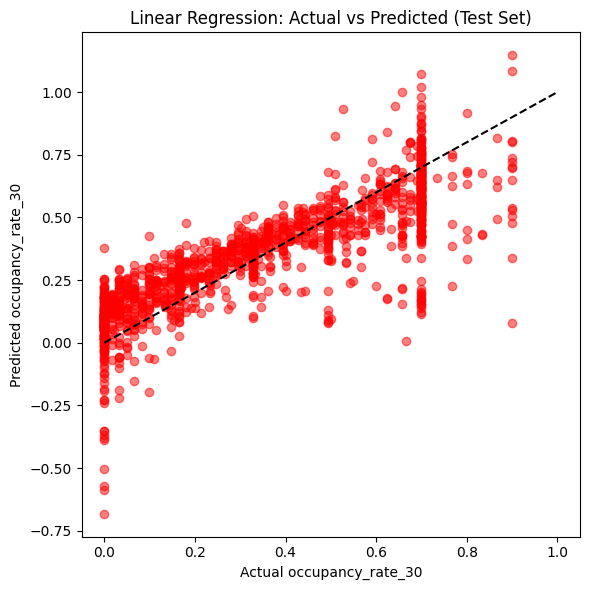

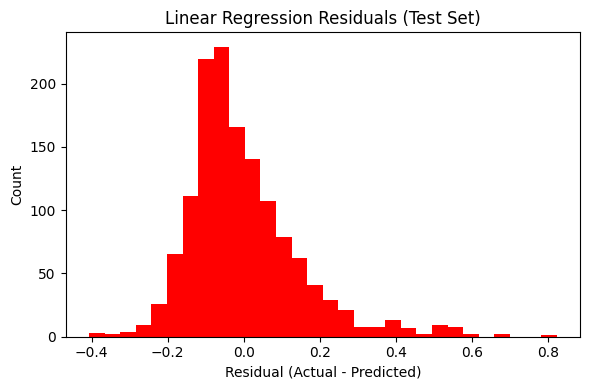

In [29]:
#  MODEL PERFORMANCE GRAPHS
#  Linear Regression – Actual vs Predicted + Residuals
linreg_pipe.fit(X_train, y_train)
y_test_pred = linreg_pipe.predict(X_test)
y_train_pred = linreg_pipe.predict(X_train)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel("Actual occupancy_rate_30")
plt.ylabel("Predicted occupancy_rate_30")
plt.title("Linear Regression: Actual vs Predicted (Test Set)")
plt.tight_layout()
plt.show()

residuals = y_test - y_test_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color='red')
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Linear Regression Residuals (Test Set)")
plt.tight_layout()
plt.show()

Model Performance Bar Chart ---> Logistic Regression/ Random Forest/ Decision Tree and Navie bayes.


Current model comparison table:

                 Model  Cutoff   TP   FP   TN  FN  Accuracy  Precision  \
0  Logistic Regression     0.4  287   60  978  48    0.9213     0.8271   
1        Random Forest     0.4  301   47  991  34    0.9410     0.8649   
2        Decision Tree     0.4  302   39  999  33    0.9476     0.8856   
3          Naive Bayes     0.4  315  803  235  20    0.4006     0.2818   

   Recall      F1  
0  0.8567  0.8416  
1  0.8985  0.8814  
2  0.9015  0.8935  
3  0.9403  0.4336  


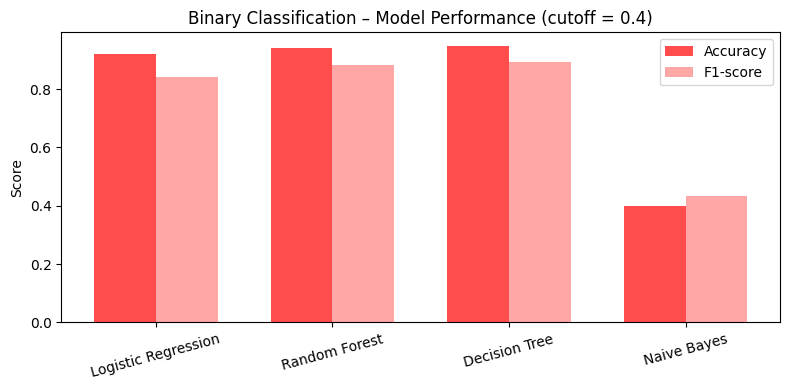

In [30]:
# Binary Classifiers – Bar Chart (Accuracy & F1) – FIXED

print("\nCurrent model comparison table:\n")
print(results_cls_df.round(4))

plt.figure(figsize=(8, 4))
x = np.arange(len(results_cls_df['Model']))
width = 0.35

plt.bar(
    x - width/2,
    results_cls_df['Accuracy'],
    width,
    label='Accuracy',
    color='red',
    alpha=0.7
)
plt.bar(
    x + width/2,
    results_cls_df['F1'],
    width,
    label='F1-score',
    color='red',
    alpha=0.35
)

plt.xticks(x, results_cls_df['Model'], rotation=15)
plt.ylabel("Score")
plt.title("Binary Classification – Model Performance (cutoff = 0.4)")
plt.legend()
plt.tight_layout()
plt.show()


Best Model --> Decision tree

In [31]:
# Decision Tree – ROC, PR, Confusion Matrix
dt_best = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_pipe = Pipeline([
    ('pp', preprocess_clf),
    ('clf', dt_best)
])
dt_pipe.fit(X_train_b, y_train_b)
y_proba_dt = dt_pipe.predict_proba(X_test_b)[:, 1]
print(y_proba_dt[:10])
print("Predictions generated:", len(y_proba_dt))

[0.         0.89473684 0.         0.         1.         0.98809524
 0.         0.96610169 0.         0.        ]
Predictions generated: 1373


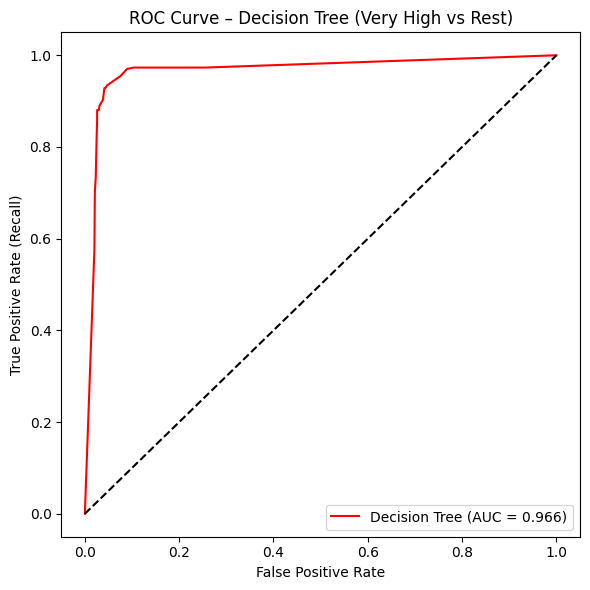

In [32]:
# ROC
fpr, tpr, _ = roc_curve(y_test_b, y_proba_dt)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})", color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Decision Tree (Very High vs Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


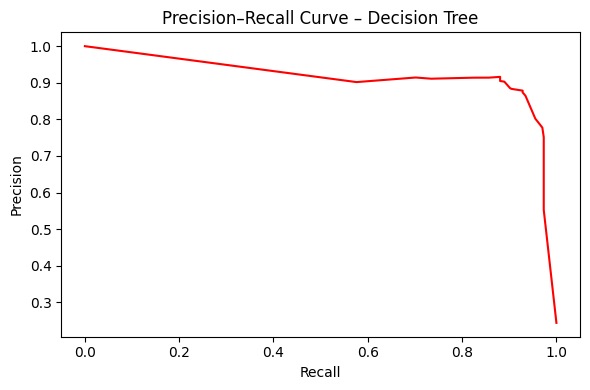

In [33]:
# Precision–Recall
prec, rec, _ = precision_recall_curve(y_test_b, y_proba_dt)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec, color='red')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Decision Tree")
plt.tight_layout()
plt.show()

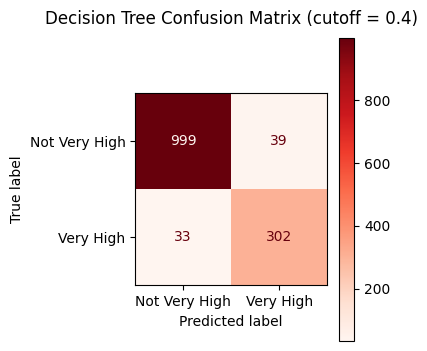

In [34]:
# Confusion Matrix at cutoff 0.4
y_pred_dt_04 = (y_proba_dt >= 0.4).astype(int)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_b,
    y_pred_dt_04,
    display_labels=["Not Very High", "Very High"],
    ax=ax,
    cmap='Reds'
)
ax.set_title("Decision Tree Confusion Matrix (cutoff = 0.4)", pad=50)
plt.tight_layout()
plt.show()

In [35]:
from sklearn.tree import export_text

# Interpretable decision tree (small depth) on the binary data
dt_interpret = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_interpret.fit(X_train_b, y_train_b)

feature_names = list(X_train_b.columns)

tree_text = export_text(dt_interpret, feature_names=feature_names)
print("\n")
print(" Decision Tree – Text Output  ")
print("_____________________________________________")
print(tree_text)




 Decision Tree – Text Output  
_____________________________________________
|--- log_estimated_revenue_30 <= 7.58
|   |--- price <= 94.50
|   |   |--- estimated_revenue_30 <= 1415.10
|   |   |   |--- estimated_revenue_30 <= 838.03
|   |   |   |   |--- class: 0
|   |   |   |--- estimated_revenue_30 >  838.03
|   |   |   |   |--- class: 0
|   |   |--- estimated_revenue_30 >  1415.10
|   |   |   |--- log_estimated_revenue_30 <= 7.33
|   |   |   |   |--- class: 1
|   |   |   |--- log_estimated_revenue_30 >  7.33
|   |   |   |   |--- class: 1
|   |--- price >  94.50
|   |   |--- availability_365 <= 22.50
|   |   |   |--- log_reviews <= 2.74
|   |   |   |   |--- class: 0
|   |   |   |--- log_reviews >  2.74
|   |   |   |   |--- class: 0
|   |   |--- availability_365 >  22.50
|   |   |   |--- number_of_reviews <= 300.50
|   |   |   |   |--- class: 0
|   |   |   |--- number_of_reviews >  300.50
|   |   |   |   |--- class: 0
|--- log_estimated_revenue_30 >  7.58
|   |--- price <= 147.50
|   

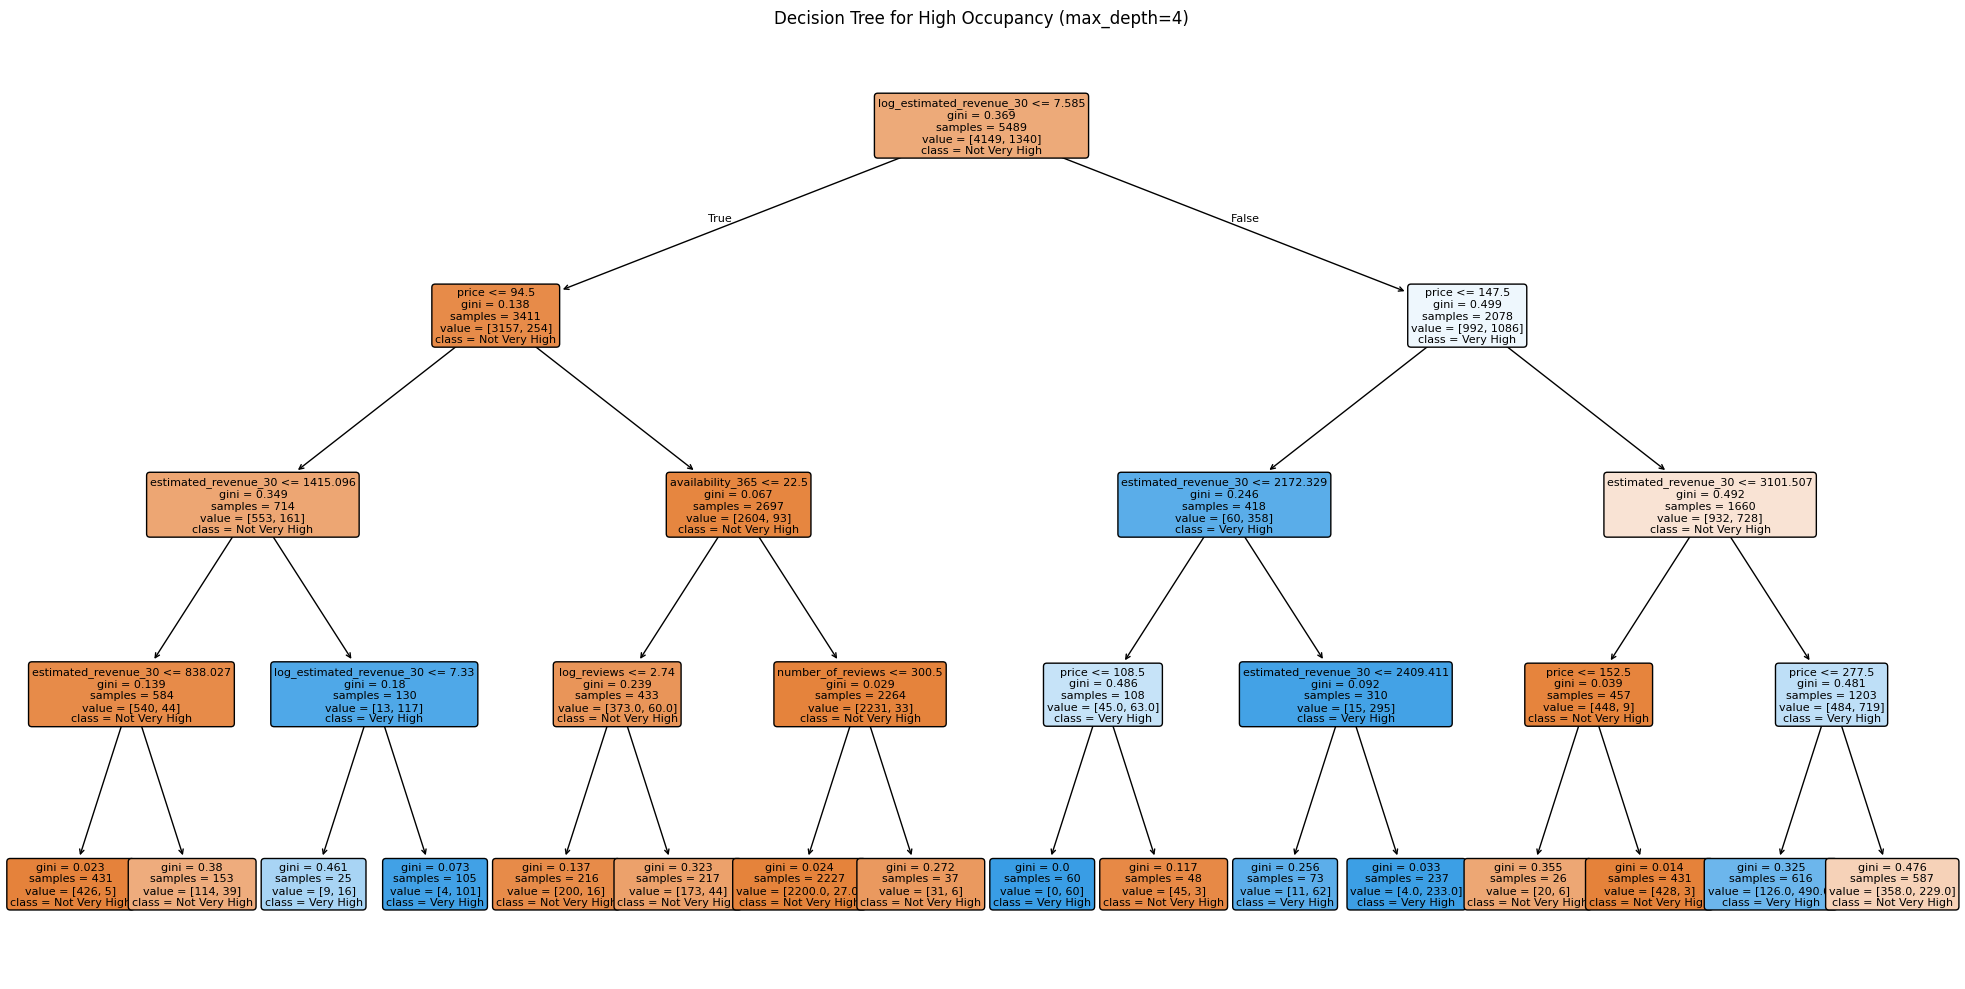

In [36]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt_interpret,
    feature_names=feature_names,
    class_names=["Not Very High", "Very High"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree for High Occupancy (max_depth=4)")
plt.tight_layout()
plt.show()


Do reviews affect occupancy

-- Occupancy Efficiency by Review Count Bin --
  review_bin  avg_occupancy_rate_30
0  0 reviews               0.207594
1       1–10               0.164873
2      11–30               0.278913
3        31+               0.469877


/tmp/ipython-input-2635009284.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('review_bin')['occupancy_rate_30']


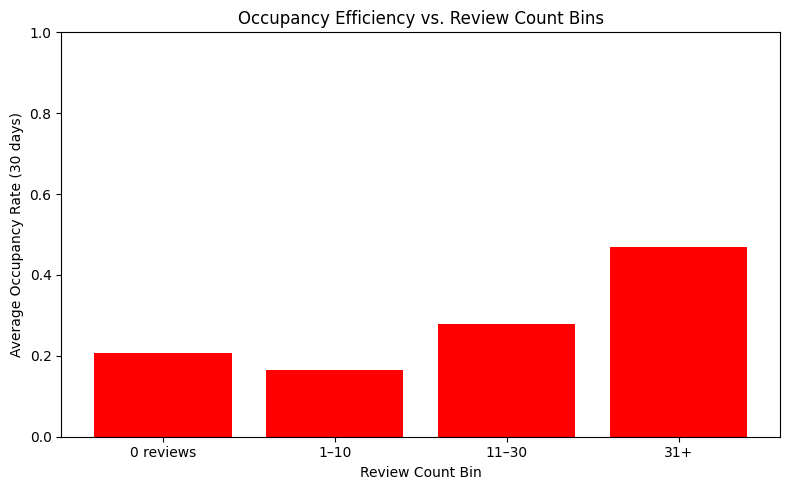

In [37]:
# DO REVIEWS AFFECT OCCUPANCY?
if {'number_of_reviews', 'occupancy_rate_30'}.issubset(df.columns):

    # Creating bins for number_of_reviews
    df['review_bin'] = pd.cut(
        df['number_of_reviews'],
        bins=[-1, 0, 10, 30, np.inf],
        labels=['0 reviews', '1–10', '11–30', '31+'],
    )

    # Compute mean occupancy_rate_30 for each bin
    occ_by_review_bin = (
        df.groupby('review_bin')['occupancy_rate_30']
          .mean()
          .reset_index()
          .rename(columns={'occupancy_rate_30': 'avg_occupancy_rate_30'})
    )

    print("-- Occupancy Efficiency by Review Count Bin --")
    print(occ_by_review_bin)

    plt.figure(figsize=(8, 5))
    plt.bar(
        occ_by_review_bin['review_bin'],
        occ_by_review_bin['avg_occupancy_rate_30'],
        color='red'
    )
    plt.title("Occupancy Efficiency vs. Review Count Bins")
    plt.xlabel("Review Count Bin")
    plt.ylabel("Average Occupancy Rate (30 days)")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for review analysis not found.")


Ocuupancy efficiency by review count

/tmp/ipython-input-305158854.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('review_bin')['occupancy_rate_30']


=== Occupancy Efficiency by Review Count Bin ===
  review_bin  avg_occupancy_rate_30
0  0 reviews               0.207594
1       1–10               0.164873
2      11–30               0.278913
3        31+               0.469877


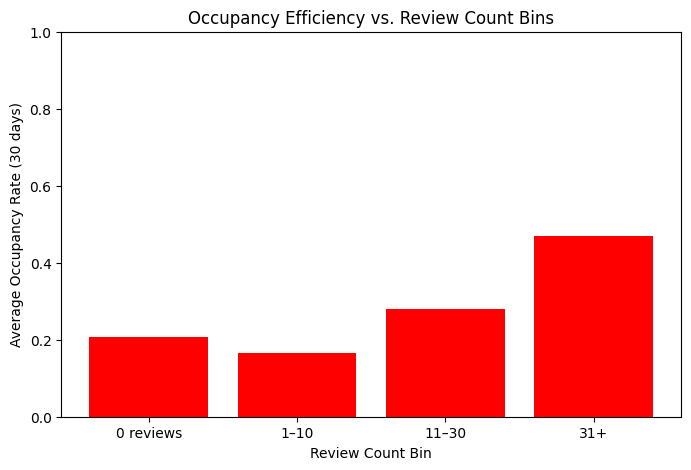

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Create bins for review_count
df['review_bin'] = pd.cut(
    df['number_of_reviews'],
    bins=[-1, 0, 10, 30, np.inf],
    labels=['0 reviews', '1–10', '11–30', '31+'],
)

#  Compute mean occupancy_rate_30 for each bin
occ_by_review_bin = (
    df.groupby('review_bin')['occupancy_rate_30']
      .mean()
      .reset_index()
      .rename(columns={'occupancy_rate_30': 'avg_occupancy_rate_30'})
)

print("=== Occupancy Efficiency by Review Count Bin ===")
print(occ_by_review_bin)

plt.figure(figsize=(8,5))
plt.bar(
    occ_by_review_bin['review_bin'],
    occ_by_review_bin['avg_occupancy_rate_30'],
    color='red'
)
plt.title("Occupancy Efficiency vs. Review Count Bins")
plt.xlabel("Review Count Bin")
plt.ylabel("Average Occupancy Rate (30 days)")
plt.ylim(0, 1)
plt.show()


SHAP Analysis

X_shap dtypes:
bool       24
float64     8
int64       5
Name: count, dtype: int64
SHAP .values shape: (5489, 37, 2)
Feature matrix shape: (5489, 37)
Class-1 SHAP shape: (5489, 37)


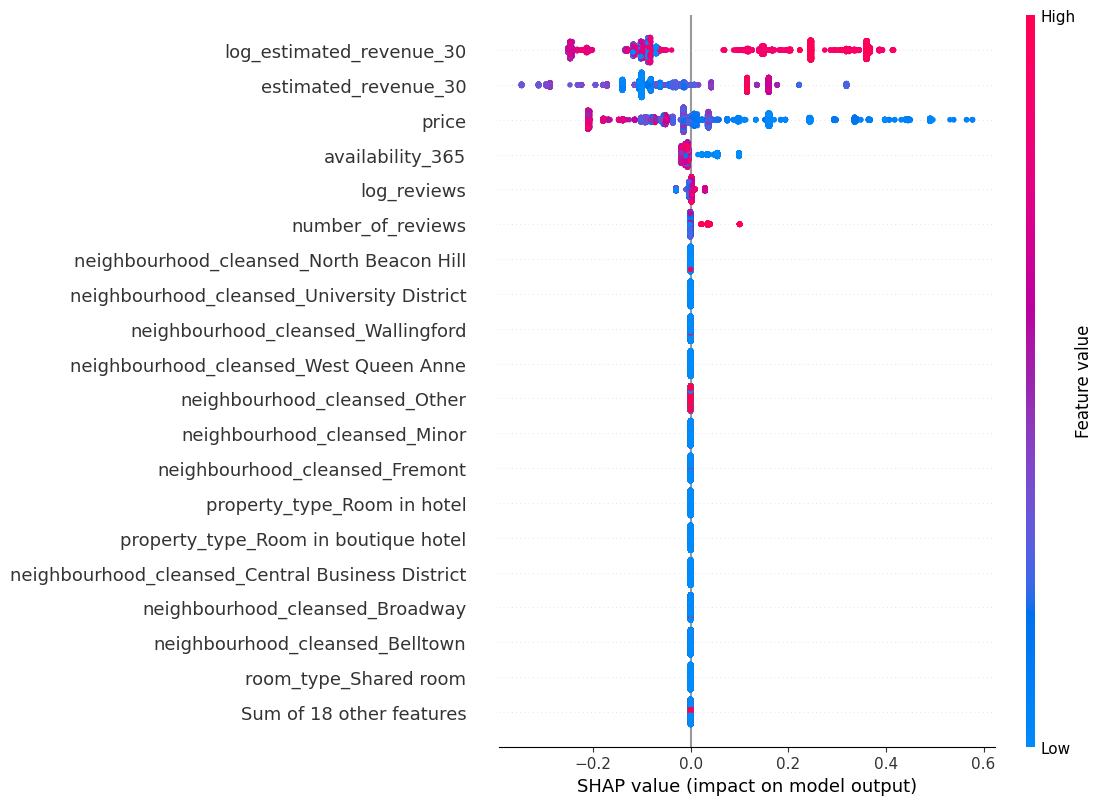

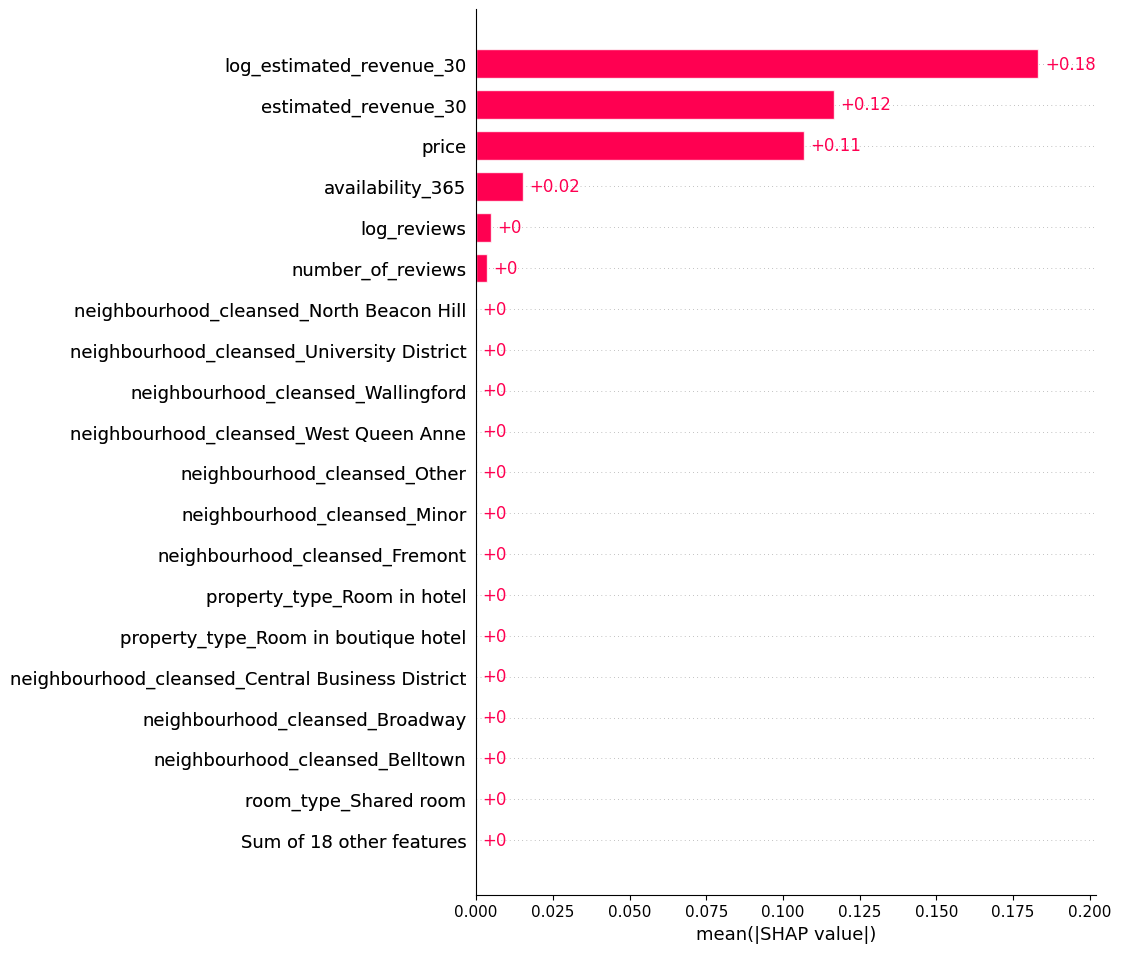

In [39]:
from sklearn.tree import DecisionTreeClassifier
import shap
import numpy as np

# Train the interpretable Decision Tree on the binary target
dt_interpret = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_interpret.fit(X_train_b, y_train_b)

# Use the same feature matrix the tree was trained on
X_shap = X_train_b.copy()

# Ensure all features are numeric (no object dtype)
X_shap = X_shap.apply(pd.to_numeric, errors='coerce').fillna(0)

print("X_shap dtypes:")
print(X_shap.dtypes.value_counts())

# Build SHAP TreeExplainer WITHOUT passing data here
explainer = shap.TreeExplainer(dt_interpret)

# Get SHAP values as an Explanation object for the same data
shap_values = explainer(X_shap)

print("SHAP .values shape:", shap_values.values.shape)   # (n_samples, n_features)
print("Feature matrix shape:", X_shap.shape)             # (n_samples, n_features)

# Take SHAP values for class 1 ("Very High" occupancy)
shap_values_class1 = shap_values[..., 1]   # now shape: (5489, 37)
print("Class-1 SHAP shape:", shap_values_class1.values.shape)


# Global importance – beeswarm
shap.initjs()

shap.plots.beeswarm(
    shap_values_class1,
    max_display=20,
    show=True
)

# Global importance – bar plot (mean |SHAP|)
shap.plots.bar(
    shap_values_class1,
    max_display=20,
    show=True
)


Dependence (scatter) for: price


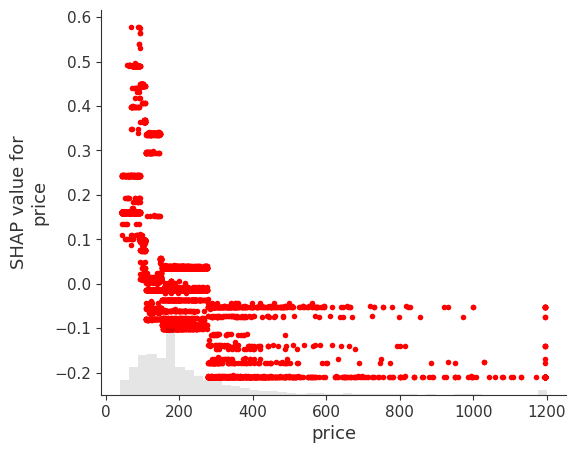

Dependence (scatter) for: availability_30


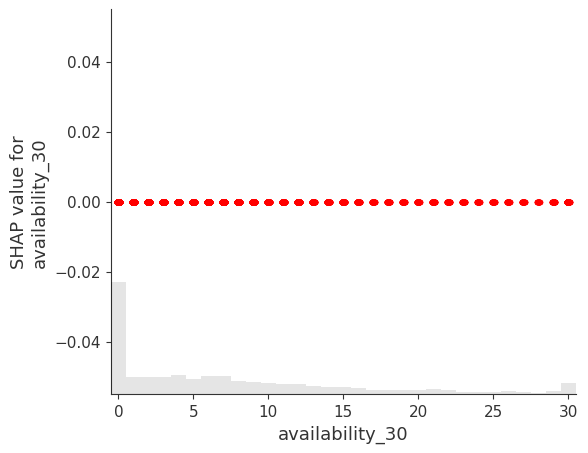

Dependence (scatter) for: number_of_reviews


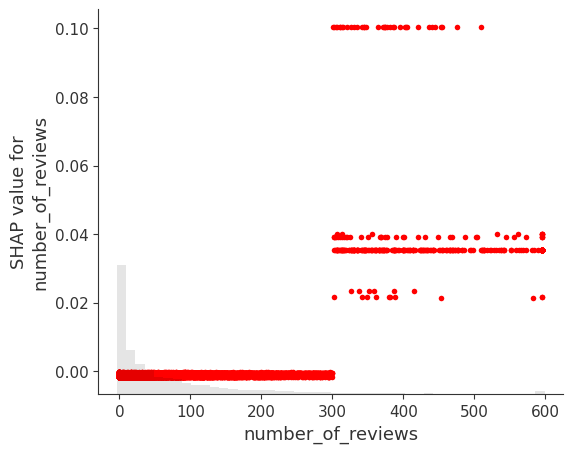

Feature 'host_response_rate' not found in X_shap (maybe dropped by VIF).
Dependence (scatter) for: host_is_superhost


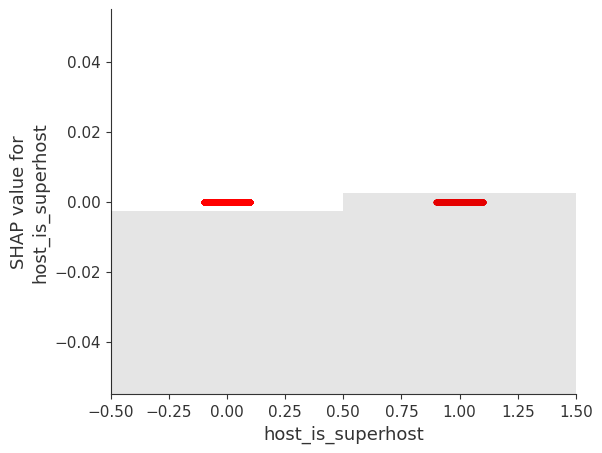

In [40]:
important_features = [
    "price",
    "availability_30",
    "number_of_reviews",
    "host_response_rate",
    "host_is_superhost"
]

for feat in important_features:
    if feat in X_shap.columns:
        print(f"Dependence (scatter) for: {feat}")
        shap.plots.scatter(
            shap_values_class1[:, feat],
            color="red",
            show=True
        )
    else:
        print(f"Feature '{feat}' not found in X_shap (maybe dropped by VIF).")
